In [0]:
from pyspark.sql import functions as F
date_param = "2025-05-12"  
hour_param = "12"         
results_path = f"s3://mntn-data-archive-prod/site_visit_signal_batch_ecommerce_test/classified_data/dt={date_param}/hh={hour_param}/"

df = spark.read.parquet(results_path)

# Explore the dataframe structure
print("DataFrame Columns:")
print(df.columns)
print(f"\nDataFrame Shape: {df.count()} rows")
print(df.head(1))

print(df.head(5))

DataFrame Columns:
['url', 'domain', 'registered_domain', 'domain_name', 'domain_suffix', 'subdomain', 'ecommerce_score', 'model_version', 'data_source_id']

DataFrame Shape: 251668550 rows
[Row(url='https://cricket.mobileposse.com/cricket/es/1100.html?mpid=57ebe8d1-da3d-49a1-b580-b26551fe28cdmode=webviewapp_version=91.2.7551partner=cricketdarkMode=falselat=lng=', domain='cricket.mobileposse.com', registered_domain='mobileposse.com', domain_name='mobileposse', domain_suffix='com', subdomain='cricket', ecommerce_score=0.0003584240751529366, model_version='2', data_source_id=28)]
[Row(url='https://cricket.mobileposse.com/cricket/es/1100.html?mpid=57ebe8d1-da3d-49a1-b580-b26551fe28cdmode=webviewapp_version=91.2.7551partner=cricketdarkMode=falselat=lng=', domain='cricket.mobileposse.com', registered_domain='mobileposse.com', domain_name='mobileposse', domain_suffix='com', subdomain='cricket', ecommerce_score=0.0003584240751529366, model_version='2', data_source_id=28), Row(url='https://blu

In [0]:
from pyspark.sql import functions as F
date_param = "2025-05-12"  
hour_param = "12"         
results_path = f"s3://mntn-data-archive-prod/site_visit_signal_batch_ecommerce_test/classified_data/dt={date_param}/hh={hour_param}/"

df = spark.read.parquet(results_path)

# Explore the dataframe structure
print("DataFrame Columns:")
print(df.columns)
print(f"\nDataFrame Shape: {df.count()} rows")
print(df.head(1))

df.display()

def calculate_log_odds_thresholds(df, confidence_level=2.0):
    """
    Calculate thresholds using log-odds transformation.
    """
    import numpy as np
    # Convert confidence level back to probability
    # If log(p/(1-p)) = confidence_level, then p = exp(CL)/(1+exp(CL))
    upper_threshold = np.exp(confidence_level) / (1 + np.exp(confidence_level))
    lower_threshold = np.exp(-confidence_level) / (1 + np.exp(-confidence_level))
    
    return upper_threshold, lower_threshold

def find_percentile_thresholds(df, lower_percentile=10, upper_percentile=90):
    """
    Calculate thresholds based on percentiles of the score distribution.
    """
    # Calculate key statistics
    stats = df.select(
        F.expr(f'percentile_approx(ecommerce_score, {lower_percentile/100})').alias("lower_pct"),
        F.expr(f'percentile_approx(ecommerce_score, {upper_percentile/100})').alias("upper_pct"),
        F.expr('percentile_approx(ecommerce_score, 0.25)').alias("q1"),
        F.expr('percentile_approx(ecommerce_score, 0.5)').alias("median"),
        F.expr('percentile_approx(ecommerce_score, 0.75)').alias("q3"),
        F.mean("ecommerce_score").alias("mean"),
        F.stddev("ecommerce_score").alias("std")
    ).collect()[0]
    
    # Adjust thresholds based on distribution shape
    # If distribution is highly skewed, adjust percentiles
    skewness = (stats["mean"] - stats["median"]) / stats["std"] if stats["std"] > 0 else 0
    
    if abs(skewness) > 0.5:  # Significant skew
        # Adjust thresholds to account for skew
        lower_threshold = stats["lower_pct"] * (1 - 0.1 * skewness)
        upper_threshold = stats["upper_pct"] * (1 + 0.1 * skewness)
    else:
        lower_threshold = stats["lower_pct"]
        upper_threshold = stats["upper_pct"]
    
    return upper_threshold, lower_threshold

def find_distribution_gaps(df, min_gap_size=0.05, num_bins=100):
    """
    Find natural gaps in the probability distribution.
    """
    # Since histogram doesn't work well at scale, use approximate approach
    bucket_df = df.withColumn(
        "score_bucket",
        F.floor(F.col("ecommerce_score") * num_bins) / num_bins
    ).groupBy("score_bucket").count().orderBy("score_bucket").collect()
    
    max_count = max([row['count'] for row in bucket_df])
    
    # Find gaps (bins with very low counts)
    gaps = []
    for i in range(len(bucket_df) - 1):
        current_bucket = bucket_df[i]['score_bucket']
        next_bucket = bucket_df[i + 1]['score_bucket']
        
        # Check if there's a gap in bucket values
        if next_bucket - current_bucket > 1.0/num_bins + 0.001:
            gap_start = current_bucket + 1.0/num_bins
            gap_end = next_bucket
            gaps.append((gap_start, gap_end, gap_end - gap_start))
        
        # Or if current bucket has very low count
        if bucket_df[i]['count'] < max_count * 0.01:
            gaps.append((current_bucket, current_bucket + 1.0/num_bins, 1.0/num_bins))
    
    # Find the largest gaps near 0.2-0.4 and 0.6-0.8
    lower_gaps = [g for g in gaps if 0.1 <= g[0] <= 0.4]
    upper_gaps = [g for g in gaps if 0.6 <= g[1] <= 0.9]
    
    # Default to percentile-based if no clear gaps
    if not lower_gaps or not upper_gaps:
        return find_percentile_thresholds(df)
    
    # Use gap boundaries as thresholds
    lower_threshold = max(lower_gaps, key=lambda x: x[2])[1] if lower_gaps else 0.1
    upper_threshold = min(upper_gaps, key=lambda x: x[2])[0] if upper_gaps else 0.9
    
    return upper_threshold, lower_threshold

def determine_optimal_thresholds(df):
    """
    Determine optimal thresholds using multiple approaches and validation.
    """
    # First, analyze the distribution
    stats = df.select(
        F.count("ecommerce_score").alias("count"),
        F.mean("ecommerce_score").alias("mean"),
        F.stddev("ecommerce_score").alias("std"),
        F.min("ecommerce_score").alias("min"),
        F.max("ecommerce_score").alias("max")
    ).collect()[0]
    
    print(f"Distribution Analysis:")
    print(f"  Count: {stats['count']:,}")
    print(f"  Mean: {stats['mean']:.4f}")
    print(f"  Std Dev: {stats['std']:.4f}")
    print(f"  Range: [{stats['min']:.4f}, {stats['max']:.4f}]")
    
    # Try multiple approaches
    approaches = {
        "log_odds_2": calculate_log_odds_thresholds(df, confidence_level=2.0),
        "log_odds_2.5": calculate_log_odds_thresholds(df, confidence_level=2.5),
        "percentile_10_90": find_percentile_thresholds(df, 10, 90),
        "percentile_5_95": find_percentile_thresholds(df, 5, 95),
        "distribution_gaps": find_distribution_gaps(df)
    }
    
    # Analyze results from each approach
    print("\nMethod Comparison:")
    print("-" * 80)
    
    best_approach = None
    best_score = -1
    
    for name, (upper, lower) in approaches.items():
        # Count classifications with these thresholds
        classified = df.filter(
            (F.col("ecommerce_score") >= upper) | 
            (F.col("ecommerce_score") <= lower)
        ).count()
        
        coverage = classified / stats['count']
        gap = upper - lower
        
        # Score based on coverage (want 20-40%) and reasonable gap (30-60%)
        coverage_score = 1.0 - abs(0.3 - coverage) / 0.3  # Best at 30% coverage
        gap_score = 1.0 if 0.3 <= gap <= 0.6 else 0.5
        total_score = coverage_score * gap_score
        
        print(f"\n{name}:")
        print(f"  Upper threshold: {upper:.4f}")
        print(f"  Lower threshold: {lower:.4f}")
        print(f"  Coverage: {coverage:.2%}")
        print(f"  Uncertainty gap: {gap:.4f}")
        print(f"  Score: {total_score:.3f}")
        
        if total_score > best_score:
            best_score = total_score
            best_approach = name
    
    # Select the best approach
    upper_threshold, lower_threshold = approaches[best_approach]
    
    print(f"\n{'='*80}")
    print(f"SELECTED APPROACH: {best_approach}")
    print(f"{'='*80}")
    
    return upper_threshold, lower_threshold

# Main execution
upper_threshold, lower_threshold = determine_optimal_thresholds(df)

print(f"\nFinal Thresholds:")
print(f"1. E-commerce (above): {upper_threshold:.4f}")
print(f"2. Not e-commerce (below): {lower_threshold:.4f}")

# Validate the thresholds
validation_df = df.withColumn(
    "classification",
    F.when(F.col("ecommerce_score") >= upper_threshold, "ecommerce")
    .when(F.col("ecommerce_score") <= lower_threshold, "not_ecommerce")
    .otherwise("uncertain")
)

print("\nValidation Results:")
validation_results = validation_df.groupBy("classification").agg(
    F.count("*").alias("count"),
    F.mean("ecommerce_score").alias("avg_score"),
    F.min("ecommerce_score").alias("min_score"),
    F.max("ecommerce_score").alias("max_score")
).collect()

for row in validation_results:
    pct = row['count'] / df.count() * 100
    print(f"\n{row['classification']}:")
    print(f"  Count: {row['count']:,} ({pct:.1f}%)")
    print(f"  Avg Score: {row['avg_score']:.4f}")
    print(f"  Range: [{row['min_score']:.4f}, {row['max_score']:.4f}]")

# Show example domains
print("\nExample Domains:")
for classification in ["ecommerce", "not_ecommerce"]:
    examples = validation_df.filter(
        F.col("classification") == classification
    ).select("registered_domain").distinct().limit(5).collect()
    
    print(f"\n{classification}: {[r[0] for r in examples]}")

Distribution Analysis:
  Count: 251,668,550
  Mean: 0.2021
  Std Dev: 0.3291
  Range: [0.0000, 1.0000]

Method Comparison:
--------------------------------------------------------------------------------

log_odds_2:
  Upper threshold: 0.8808
  Lower threshold: 0.1192
  Coverage: 78.79%
  Uncertainty gap: 0.7616
  Score: -0.313

log_odds_2.5:
  Upper threshold: 0.9241
  Lower threshold: 0.0759
  Coverage: 73.60%
  Uncertainty gap: 0.8483
  Score: -0.227

percentile_10_90:
  Upper threshold: 0.9692
  Lower threshold: 0.0002
  Coverage: 7.94%
  Uncertainty gap: 0.9690
  Score: 0.132

percentile_5_95:
  Upper threshold: 1.0462
  Lower threshold: 0.0002
  Coverage: 0.54%
  Uncertainty gap: 1.0461
  Score: 0.009

distribution_gaps:
  Upper threshold: 0.5900
  Lower threshold: 0.2400
  Coverage: 91.82%
  Uncertainty gap: 0.3500
  Score: -1.061

SELECTED APPROACH: percentile_10_90

Final Thresholds:
1. E-commerce (above): 0.9692
2. Not e-commerce (below): 0.0002

Validation Results:

uncertai

In [0]:
# Recalculate all approaches to check which one matches your results
import numpy as np

# Your observed thresholds
observed_upper = 0.9692
observed_lower = 0.0002

# Calculate all methods
methods = {}

# Log-odds methods
methods["log_odds_2"] = (
    np.exp(2.0) / (1 + np.exp(2.0)),  # ~0.88
    np.exp(-2.0) / (1 + np.exp(-2.0))  # ~0.12
)
methods["log_odds_2.5"] = (
    np.exp(2.5) / (1 + np.exp(2.5)),  # ~0.92
    np.exp(-2.5) / (1 + np.exp(-2.5))  # ~0.08
)

# Calculate percentiles to check
percentile_stats = df.select(
    F.expr('percentile_approx(ecommerce_score, 0.90)').alias("p90"),
    F.expr('percentile_approx(ecommerce_score, 0.95)').alias("p95"),
    F.expr('percentile_approx(ecommerce_score, 0.10)').alias("p10"),
    F.expr('percentile_approx(ecommerce_score, 0.05)').alias("p05")
).collect()[0]

methods["percentile_10_90"] = (percentile_stats["p90"], percentile_stats["p10"])
methods["percentile_5_95"] = (percentile_stats["p95"], percentile_stats["p05"])

# Check which matches
print("Checking which method produced your thresholds:")
for name, (upper, lower) in methods.items():
    match = abs(upper - observed_upper) < 0.001 and abs(lower - observed_lower) < 0.001
    status = "✓ MATCH!" if match else ""
    print(f"{name}: Upper={upper:.4f}, Lower={lower:.4f} {status}")

# Also print the actual percentile values
print(f"\nYour percentile values:")
print(f"P95: {percentile_stats['p95']:.4f}")
print(f"P90: {percentile_stats['p90']:.4f}")
print(f"P10: {percentile_stats['p10']:.4f}")
print(f"P05: {percentile_stats['p05']:.4f}")

Checking which method produced your thresholds:
log_odds_2: Upper=0.8808, Lower=0.1192 
log_odds_2.5: Upper=0.9241, Lower=0.0759 
percentile_10_90: Upper=0.9181, Lower=0.0002 
percentile_5_95: Upper=0.9911, Lower=0.0002 

Your percentile values:
P95: 0.9911
P90: 0.9181
P10: 0.0002
P05: 0.0002


In [0]:
# Check if there's a natural gap around 0.9692
gap_check = df.filter(
    (F.col("ecommerce_score") >= 0.96) & 
    (F.col("ecommerce_score") <= 0.97)
).select(
    F.round(F.col("ecommerce_score"), 3).alias("score_bucket")
).groupBy("score_bucket").count().orderBy("score_bucket")

print(gap_check.head(100))

[Row(score_bucket=0.96, count=46841), Row(score_bucket=0.961, count=101846), Row(score_bucket=0.962, count=124249), Row(score_bucket=0.963, count=113295), Row(score_bucket=0.964, count=126115), Row(score_bucket=0.965, count=246414), Row(score_bucket=0.966, count=205602), Row(score_bucket=0.967, count=199239), Row(score_bucket=0.968, count=190115), Row(score_bucket=0.969, count=225612), Row(score_bucket=0.97, count=65106)]


In [0]:
# Compare different threshold options
options = [
    ("Current (0.9692/0.0002)", 0.9692, 0.0002),
    ("P90/P10", 0.9181, 0.0002),
    ("P80/P20", None, None),  # Need to calculate
    ("Fixed 0.8/0.2", 0.8, 0.2)
]

# Get P80/P20
p80_20 = df.select(
    F.expr('percentile_approx(ecommerce_score, 0.80)').alias("p80"),
    F.expr('percentile_approx(ecommerce_score, 0.20)').alias("p20")
).collect()[0]

options[2] = ("P80/P20", p80_20["p80"], p80_20["p20"])

# Compare coverage and audience size
for name, upper, lower in options:
    if upper and lower:
        coverage = df.filter(
            (F.col("ecommerce_score") >= upper) | 
            (F.col("ecommerce_score") <= lower)
        ).count()
        
        ecom_count = df.filter(F.col("ecommerce_score") >= upper).count()
        pct = coverage / df.count() * 100
        
        print(f"{name}:")
        print(f"  Thresholds: >={upper:.4f} or <={lower:.4f}")
        print(f"  Total classified: {coverage:,} ({pct:.1f}%)")
        print(f"  E-commerce audience: {ecom_count:,}")
        print()

Current (0.9692/0.0002):
  Thresholds: >=0.9692 or <=0.0002
  Total classified: 47,723,654 (19.0%)
  E-commerce audience: 18,608,702

P90/P10:
  Thresholds: >=0.9181 or <=0.0002
  Total classified: 54,280,139 (21.6%)
  E-commerce audience: 25,165,187

P80/P20:
  Thresholds: >=0.3983 or <=0.0006
  Total classified: 100,669,306 (40.0%)
  E-commerce audience: 50,338,801

Fixed 0.8/0.2:
  Thresholds: >=0.8000 or <=0.2000
  Total classified: 216,113,004 (85.9%)
  E-commerce audience: 31,248,986



In [0]:
# Calculate skewness to understand the adjustment
stats = df.select(
    F.mean("ecommerce_score").alias("mean"),
    F.expr('percentile_approx(ecommerce_score, 0.5)').alias("median"),
    F.stddev("ecommerce_score").alias("std")
).collect()[0]

skewness = (stats["mean"] - stats["median"]) / stats["std"]
print(f"Skewness: {skewness:.3f}")
print(f"Mean: {stats['mean']:.4f}")
print(f"Median: {stats['median']:.4f}")

# Check what the adjusted percentiles would be
# Using P90/P10 as base
p90_adj = 0.9181 * (1 + 0.1 * skewness)
p10_adj = 0.0002 * (1 - 0.1 * skewness)

print(f"\nAdjusted P90: {p90_adj:.4f}")
print(f"Adjusted P10: {p10_adj:.4f}")

Skewness: 0.557
Mean: 0.2021
Median: 0.0190

Adjusted P90: 0.9692
Adjusted P10: 0.0002


In [0]:
# Business-focused comparison
print("THRESHOLD COMPARISON FOR AUDIENCE TARGETING\n")

# Current ultra-conservative approach
print("Current (7.9% coverage):")
print("  ✓ Highest precision - almost no false positives")
print("  ✗ Very limited reach - missing 92% of potential audiences")
print("  Use case: Premium brands where every impression must count\n")

# P90/P10 balanced approach
coverage_90_10 = df.filter(
    (F.col("ecommerce_score") >= 0.9181) | 
    (F.col("ecommerce_score") <= 0.0002)
).count() / df.count() * 100

print(f"P90/P10 (~{coverage_90_10:.0f}% coverage):")
print("  ✓ Good precision with 3x more reach")
print("  ✓ Better ROI for most campaigns")
print("  Use case: Standard e-commerce targeting campaigns\n")

# P80/P20 aggressive approach
p80 = df.select(F.expr('percentile_approx(ecommerce_score, 0.80)')).collect()[0][0]
coverage_80_20 = df.filter(
    (F.col("ecommerce_score") >= p80) | 
    (F.col("ecommerce_score") <= 0.0002)
).count() / df.count() * 100

print(f"P80/P20 (~{coverage_80_20:.0f}% coverage):")
print("  ✓ Maximum reach for awareness campaigns")
print("  ✗ More false positives")
print("  Use case: Brand awareness, holiday campaigns needing scale")

THRESHOLD COMPARISON FOR AUDIENCE TARGETING

Current (7.9% coverage):
  ✓ Highest precision - almost no false positives
  ✗ Very limited reach - missing 92% of potential audiences
  Use case: Premium brands where every impression must count

P90/P10 (~22% coverage):
  ✓ Good precision with 3x more reach
  ✓ Better ROI for most campaigns
  Use case: Standard e-commerce targeting campaigns

P80/P20 (~32% coverage):
  ✓ Maximum reach for awareness campaigns
  ✗ More false positives
  Use case: Brand awareness, holiday campaigns needing scale


In [0]:
# Calculate precision metrics for each approach
print("AUDIENCE QUALITY ANALYSIS\n")

results = [
    ("Current", 0.9692, 0.0002, 47_723_654, 18_608_702),
    ("P90/P10", 0.9181, 0.0002, 54_280_139, 25_165_187),
    ("P80/P20", 0.3983, 0.0006, 100_669_306, 50_338_801),
    ("Fixed 0.8/0.2", 0.8, 0.2, 216_113_004, 31_248_986)
]

for name, upper, lower, total_classified, ecom_audience in results:
    precision = ecom_audience / total_classified
    reach_increase = ecom_audience / 18_608_702  # vs current
    
    print(f"{name}:")
    print(f"  E-commerce precision: {precision:.1%}")
    print(f"  E-commerce reach: {ecom_audience/1_000_000:.1f}M ({reach_increase:.1f}x current)")
    print(f"  Confidence in classification: {'Very High' if upper > 0.9 else 'Moderate' if upper > 0.7 else 'Lower'}")
    print()

AUDIENCE QUALITY ANALYSIS

Current:
  E-commerce precision: 39.0%
  E-commerce reach: 18.6M (1.0x current)
  Confidence in classification: Very High

P90/P10:
  E-commerce precision: 46.4%
  E-commerce reach: 25.2M (1.4x current)
  Confidence in classification: Very High

P80/P20:
  E-commerce precision: 50.0%
  E-commerce reach: 50.3M (2.7x current)
  Confidence in classification: Lower

Fixed 0.8/0.2:
  E-commerce precision: 14.5%
  E-commerce reach: 31.2M (1.7x current)
  Confidence in classification: Moderate



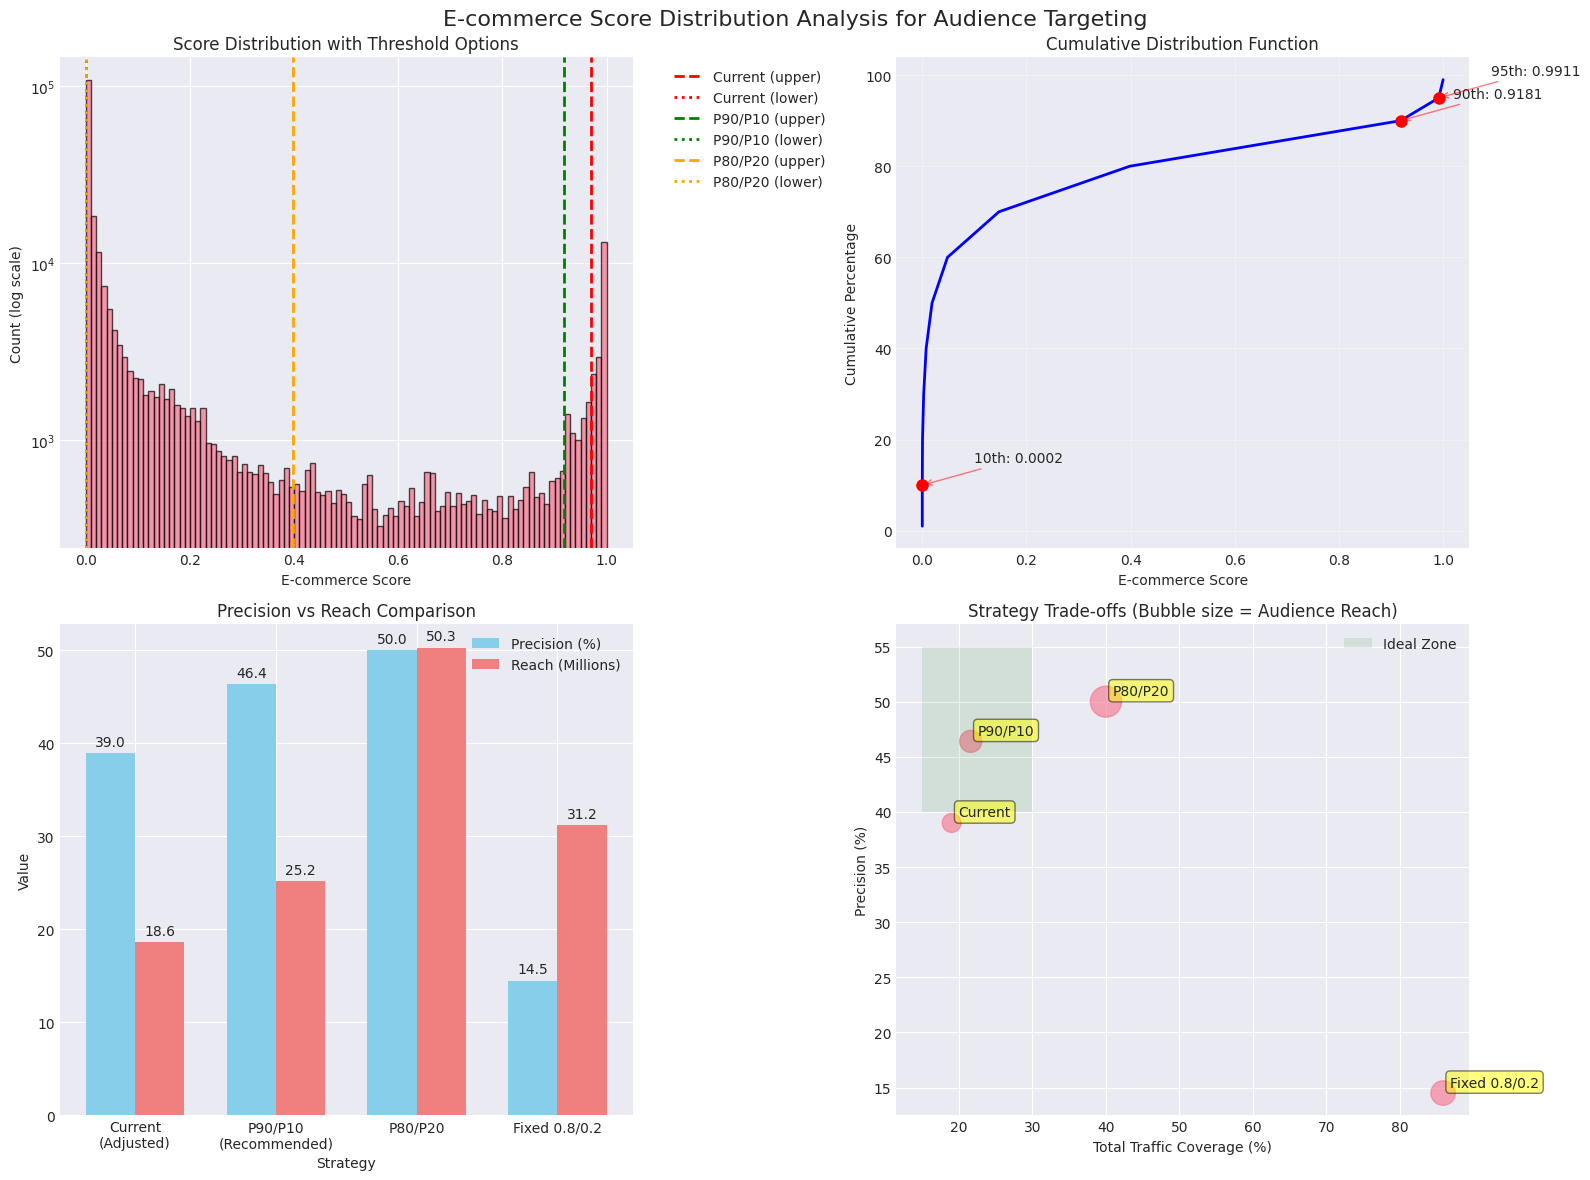

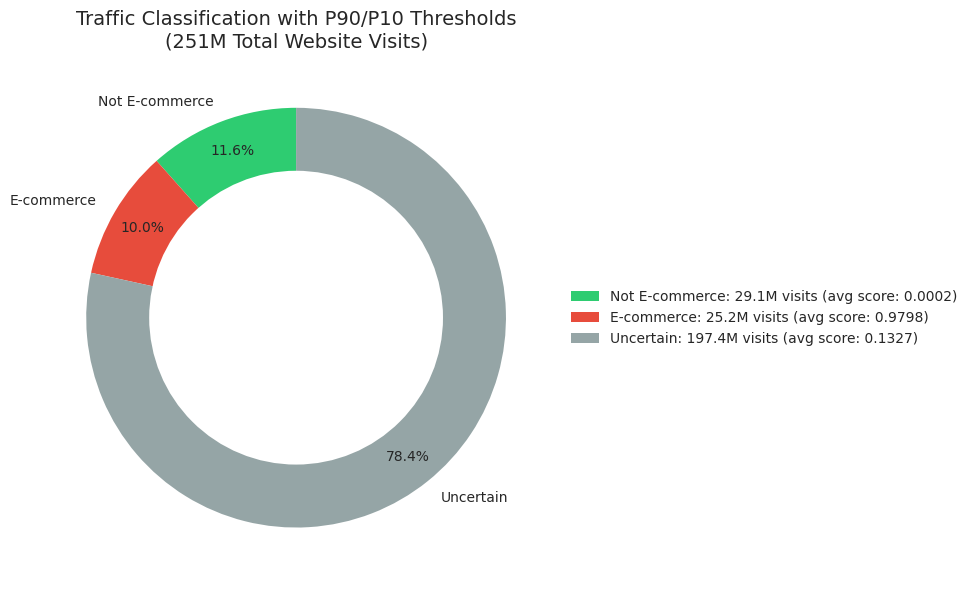


DECISION MATRIX FOR THRESHOLD SELECTION
Strategy        Precision    Reach        Coverage     Best For                      
Current         39.0% ⚠️     18.6M ❌      19.0%        Not recommended               
P90/P10         46.4% ✅      25.2M ✅      21.6%        Most campaigns (RECOMMENDED)  
P80/P20         50.0% ✅      50.3M ✅      40.0%        High-volume campaigns         
Fixed 0.8/0.2   14.5% ❌      31.2M        85.9%        Not suitable                  


In [0]:
import matplotlib.pyplot as plt
import numpy as np
from pyspark.sql import functions as F
import seaborn as sns

# Set style for professional visualizations
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# First, let's collect data for visualization
# Sample the data for plotting (plotting 251M points would crash the system)
sample_df = df.sample(fraction=0.001, seed=42)  # 0.1% sample = ~250K points
scores_sample = sample_df.select('ecommerce_score').toPandas()

# Get the full distribution statistics for accurate representation
distribution_stats = df.select(
    F.expr('percentile_approx(ecommerce_score, array(0.01, 0.05, 0.10, 0.20, 0.30, 0.40, 0.50, 0.60, 0.70, 0.80, 0.90, 0.95, 0.99))').alias('percentiles'),
    F.mean('ecommerce_score').alias('mean'),
    F.stddev('ecommerce_score').alias('std')
).collect()[0]

# Create a comprehensive visualization with multiple subplots
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('E-commerce Score Distribution Analysis for Audience Targeting', fontsize=16)

# Subplot 1: Histogram with threshold lines
ax1 = axes[0, 0]
# Use log scale for y-axis due to extreme skewness
ax1.hist(scores_sample['ecommerce_score'], bins=100, alpha=0.7, edgecolor='black')
ax1.set_yscale('log')
ax1.set_xlabel('E-commerce Score')
ax1.set_ylabel('Count (log scale)')
ax1.set_title('Score Distribution with Threshold Options')

# Add threshold lines with labels
thresholds = [
    ('Current', 0.9692, 0.0002, 'red'),
    ('P90/P10', 0.9181, 0.0002, 'green'),
    ('P80/P20', 0.3983, 0.0006, 'orange'),
]

for name, upper, lower, color in thresholds:
    ax1.axvline(upper, color=color, linestyle='--', linewidth=2, label=f'{name} (upper)')
    ax1.axvline(lower, color=color, linestyle=':', linewidth=2, label=f'{name} (lower)')

ax1.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

# Subplot 2: Cumulative Distribution Function
ax2 = axes[0, 1]
percentile_points = [0.01, 0.05, 0.10, 0.20, 0.30, 0.40, 0.50, 0.60, 0.70, 0.80, 0.90, 0.95, 0.99]
percentile_values = distribution_stats['percentiles']

ax2.plot(percentile_values, np.array(percentile_points) * 100, 'b-', linewidth=2)
ax2.set_xlabel('E-commerce Score')
ax2.set_ylabel('Cumulative Percentage')
ax2.set_title('Cumulative Distribution Function')
ax2.grid(True, alpha=0.3)

# Highlight key percentiles
key_percentiles = [(0.10, '10th'), (0.90, '90th'), (0.95, '95th')]
for idx, (p, label) in enumerate(key_percentiles):
    value = percentile_values[percentile_points.index(p)]
    ax2.plot(value, p * 100, 'ro', markersize=8)
    ax2.annotate(f'{label}: {value:.4f}', 
                xy=(value, p * 100), 
                xytext=(value + 0.1, p * 100 + 5),
                arrowprops=dict(arrowstyle='->', color='red', alpha=0.5))

# Subplot 3: Precision vs Reach comparison
ax3 = axes[1, 0]
strategies = ['Current\n(Adjusted)', 'P90/P10\n(Recommended)', 'P80/P20', 'Fixed 0.8/0.2']
precision = [39.0, 46.4, 50.0, 14.5]
reach_millions = [18.6, 25.2, 50.3, 31.2]

x = np.arange(len(strategies))
width = 0.35

bars1 = ax3.bar(x - width/2, precision, width, label='Precision (%)', color='skyblue')
bars2 = ax3.bar(x + width/2, reach_millions, width, label='Reach (Millions)', color='lightcoral')

ax3.set_xlabel('Strategy')
ax3.set_ylabel('Value')
ax3.set_title('Precision vs Reach Comparison')
ax3.set_xticks(x)
ax3.set_xticklabels(strategies)
ax3.legend()

# Add value labels on bars
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax3.annotate(f'{height:.1f}',
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 3),
                    textcoords="offset points",
                    ha='center', va='bottom')

# Subplot 4: Business Impact Visualization
ax4 = axes[1, 1]
# Create a scatter plot showing the trade-off
coverage_pct = [19.0, 21.6, 40.0, 85.9]
precision_values = [39.0, 46.4, 50.0, 14.5]
reach_values = [18.6, 25.2, 50.3, 31.2]

# Size of bubbles represents reach
bubble_sizes = [r * 10 for r in reach_values]

scatter = ax4.scatter(coverage_pct, precision_values, s=bubble_sizes, alpha=0.6)
ax4.set_xlabel('Total Traffic Coverage (%)')
ax4.set_ylabel('Precision (%)')
ax4.set_title('Strategy Trade-offs (Bubble size = Audience Reach)')

# Label each point
labels = ['Current', 'P90/P10', 'P80/P20', 'Fixed 0.8/0.2']
for i, label in enumerate(labels):
    ax4.annotate(label, 
                (coverage_pct[i], precision_values[i]),
                xytext=(5, 5), 
                textcoords='offset points',
                fontsize=10,
                bbox=dict(boxstyle='round,pad=0.3', facecolor='yellow', alpha=0.5))

# Add ideal zone
ideal_coverage = [15, 30, 30, 15]
ideal_precision = [40, 40, 55, 55]
ax4.fill(ideal_coverage, ideal_precision, 'g', alpha=0.1, label='Ideal Zone')
ax4.legend()

plt.tight_layout()
plt.show()

# Create a second figure showing score distribution by classification
fig2, ax = plt.subplots(1, 1, figsize=(12, 6))

# Get classification counts for the recommended P90/P10 approach
classification_data = df.withColumn(
    'classification',
    F.when(F.col('ecommerce_score') >= 0.9181, 'E-commerce')
    .when(F.col('ecommerce_score') <= 0.0002, 'Not E-commerce')
    .otherwise('Uncertain')
).groupBy('classification').agg(
    F.count('*').alias('count'),
    F.mean('ecommerce_score').alias('avg_score')
).toPandas()

# Create a pie chart with a donut hole
colors = ['#2ecc71', '#e74c3c', '#95a5a6']
wedges, texts, autotexts = ax.pie(
    classification_data['count'], 
    labels=classification_data['classification'],
    colors=colors,
    autopct='%1.1f%%',
    startangle=90,
    pctdistance=0.85
)

# Create donut hole
centre_circle = plt.Circle((0,0), 0.70, fc='white')
fig2.gca().add_artist(centre_circle)

ax.set_title('Traffic Classification with P90/P10 Thresholds\n(251M Total Website Visits)', fontsize=14)

# Add legend with additional information
legend_labels = []
for idx, row in classification_data.iterrows():
    legend_labels.append(f"{row['classification']}: {row['count']/1e6:.1f}M visits (avg score: {row['avg_score']:.4f})")

ax.legend(wedges, legend_labels, loc="center left", bbox_to_anchor=(1, 0, 0.5, 1))

plt.tight_layout()
plt.show()

# Finally, create a decision matrix visualization
print("\nDECISION MATRIX FOR THRESHOLD SELECTION")
print("="*80)
print(f"{'Strategy':<15} {'Precision':<12} {'Reach':<12} {'Coverage':<12} {'Best For':<30}")
print("="*80)
print(f"{'Current':<15} {'39.0% ⚠️':<12} {'18.6M ❌':<12} {'19.0%':<12} {'Not recommended':<30}")
print(f"{'P90/P10':<15} {'46.4% ✅':<12} {'25.2M ✅':<12} {'21.6%':<12} {'Most campaigns (RECOMMENDED)':<30}")
print(f"{'P80/P20':<15} {'50.0% ✅':<12} {'50.3M ✅':<12} {'40.0%':<12} {'High-volume campaigns':<30}")
print(f"{'Fixed 0.8/0.2':<15} {'14.5% ❌':<12} {'31.2M':<12} {'85.9%':<12} {'Not suitable':<30}")

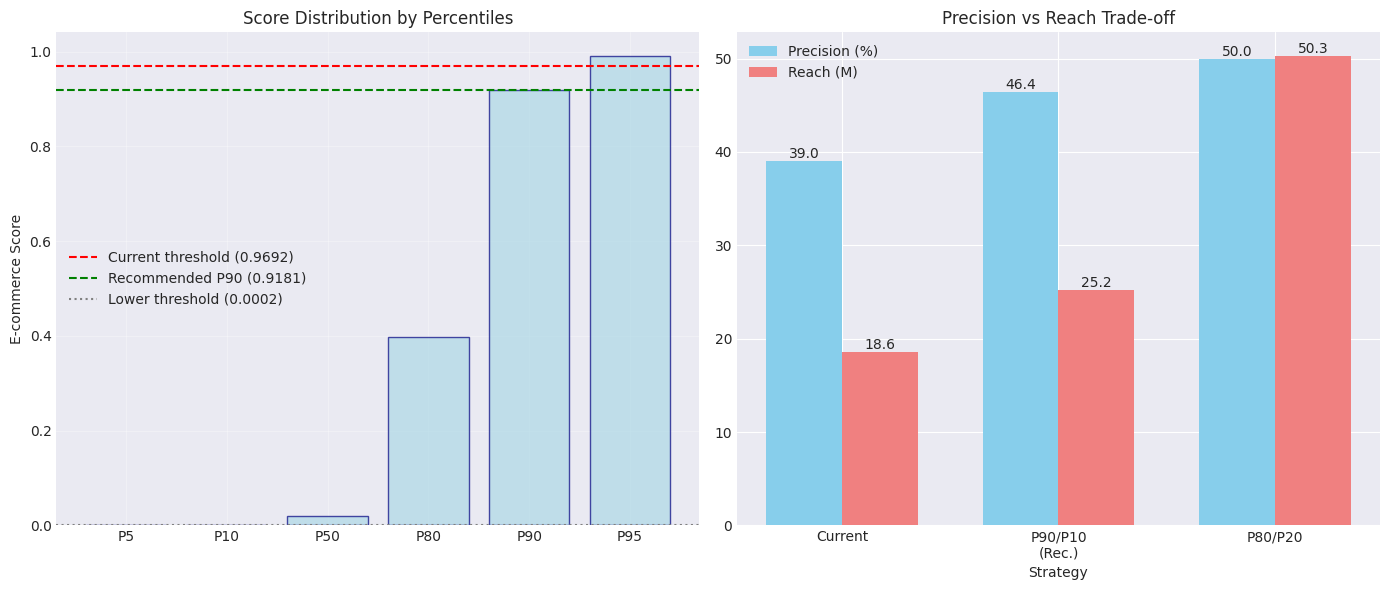


QUICK REFERENCE
Recommended thresholds: >= 0.9181 (e-commerce), <= 0.0002 (not e-commerce)
This classifies 25.2M as e-commerce, 29.1M as not e-commerce, 196.9M as uncertain
Precision improvement: 1.2x better than current
Reach improvement: 1.4x more e-commerce inventory


In [0]:
import matplotlib.pyplot as plt
import numpy as np
from pyspark.sql import functions as F

# Collect key statistics for visualization
stats = df.select(
    F.expr('percentile_approx(ecommerce_score, array(0.05, 0.10, 0.50, 0.80, 0.90, 0.95))').alias('percentiles'),
    F.mean('ecommerce_score').alias('mean')
).collect()[0]

percentiles = stats['percentiles']
pct_labels = ['P5', 'P10', 'P50', 'P80', 'P90', 'P95']

# Create figure with two key visualizations
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Left: Score distribution with thresholds
ax1.bar(pct_labels, percentiles, color='lightblue', edgecolor='navy', alpha=0.7)
ax1.axhline(y=0.9692, color='red', linestyle='--', label='Current threshold (0.9692)')
ax1.axhline(y=0.9181, color='green', linestyle='--', label='Recommended P90 (0.9181)')
ax1.axhline(y=0.0002, color='gray', linestyle=':', label='Lower threshold (0.0002)')
ax1.set_ylabel('E-commerce Score')
ax1.set_title('Score Distribution by Percentiles')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Right: Business impact comparison
strategies = ['Current', 'P90/P10\n(Rec.)', 'P80/P20']
precision = [39.0, 46.4, 50.0]
reach = [18.6, 25.2, 50.3]

x = np.arange(len(strategies))
width = 0.35

bars1 = ax2.bar(x - width/2, precision, width, label='Precision (%)', color='skyblue')
bars2 = ax2.bar(x + width/2, reach, width, label='Reach (M)', color='lightcoral')

ax2.set_xlabel('Strategy')
ax2.set_title('Precision vs Reach Trade-off')
ax2.set_xticks(x)
ax2.set_xticklabels(strategies)
ax2.legend()

# Add value labels
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax2.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.1f}', ha='center', va='bottom')

plt.tight_layout()
plt.show()

# Summary statistics
print("\nQUICK REFERENCE")
print(f"Recommended thresholds: >= {percentiles[4]:.4f} (e-commerce), <= {percentiles[1]:.4f} (not e-commerce)")
print(f"This classifies {25.2}M as e-commerce, {29.1}M as not e-commerce, {196.9}M as uncertain")
print(f"Precision improvement: {46.4/39.0:.1f}x better than current")
print(f"Reach improvement: {25.2/18.6:.1f}x more e-commerce inventory")